# Analysis based on DL-Hard Dataset

This part is based on the dataset called DL-Hard, which is an annotated dataset buiilt upon TREC Deep Learning questions. The questions are annotated with query intent categories based on the paper An Intent Taxonomy for Questions Asked in Web Search (https://marksanderson.org/files/papers/CHIIR21b.pdf) and answer type which is a manual annotation of target answer type for we questions (short answer, factoid etc). They also identified 50 hard questions from the ~100 TREC DL 2019/2020 dataset, which we use to compare QE technique performance on hard and non-hard queries. 

## Grouping queries based on query intent and answer type

In [1]:
import pyterrier as pt
import pandas as pd

dataset = pt.get_dataset("msmarco_passage")
index = dataset.get_index(variant="terrier_stemmed")

# Load DL-hard annotations
annotations_url = "https://raw.githubusercontent.com/grill-lab/DL-Hard/main/annotations/query/annotations.tsv"
annotations = pd.read_csv(
    annotations_url,
    sep="\t",
    header=None,
    names=["qid", "query", "intent", "answer_type", "topic_domain", "serp_type"],
)
annotations["qid"] = annotations["qid"].astype(str)

# Load TREC DL 2019/2020 qrels. This dataset contains relevance judgements from scale 0 to 3.
dl19 = pt.get_dataset("irds:msmarco-passage/trec-dl-2019")
dl20 = pt.get_dataset("irds:msmarco-passage/trec-dl-2020")
all_qrels = pd.concat([dl19.get_qrels(), dl20.get_qrels()])
all_qrels["qid"] = all_qrels["qid"].astype(str)

# Keep only queries that have both annotations and judgements.
qrels_qids = set(all_qrels["qid"].unique())
topics = annotations[annotations["qid"].isin(qrels_qids)].reset_index(drop=True)
print(f"Queries with both annotations and relevance values: {len(topics)}")
print(topics["intent"].value_counts())
print("\n")
print(topics["answer_type"].value_counts())

Queries with both annotations and relevance values: 97
intent
description     48
list            10
quantity         9
reason           8
attribute        7
entity           5
verification     3
process          3
language         3
weather          1
Name: count, dtype: int64


answer_type
factoid              28
definition           21
long answer          16
list                 10
short description     7
short answer          5
comparison            5
guide                 2
weather               1
Long answer           1
multi-answer          1
Name: count, dtype: int64


In [2]:
intent_map = {
    "description": "Explanatory",
    "reason": "Explanatory",
    "process": "Explanatory",
    "entity": "Factual-Lookup",
    "attribute": "Factual-Lookup",
    "verification": "Factual-Lookup",
    "language": "Factual-Lookup",
    "list": "Explanatory",
    "quantity": "Factual-Lookup",
    "weather": "Factual-Lookup",
}

answer_map = {
    "definition": "Definitional",
    "long answer": "Extended",
    "Long answer": "Extended",
    "short description": "Extended",
    "guide": "Extended",
    "factoid": "Factoid",
    "short answer": "Factoid",
    "weather": "Factoid",
    "list": "Extended",
    "comparison": "Extended",
    "multi-answer": "Extended",
}
topics["meta_intent"] = topics["intent"].map(intent_map)
print(topics["meta_intent"].value_counts(), "\n")
topics["meta_answer_type"] = topics["answer_type"].map(answer_map)
print(topics["meta_answer_type"].value_counts())

meta_intent
Explanatory       69
Factual-Lookup    28
Name: count, dtype: int64 

meta_answer_type
Extended        42
Factoid         34
Definitional    21
Name: count, dtype: int64


## Classical QE techniques

In [3]:
import re

def clean_query(q):
    q = re.sub(r"[^\w\s]", " ", str(q))
    q = re.sub(r"\s+", " ", q).strip()
    return q

# Clean queries (else it gives errors in PyTerrier)
topics["query"] = topics["query"].apply(clean_query)

# Initialize BM25 retriever
bm25 = pt.terrier.Retriever(index, wmodel="BM25")

# Initialize classic query expansion models
rm3 = pt.rewrite.RM3(index, fb_terms=10, fb_docs=3)
bo1 = pt.rewrite.Bo1QueryExpansion(index, fb_terms=10, fb_docs=3)

bm25_rm3 = bm25 >> rm3 >> bm25
bm25_bo1 = bm25 >> bo1 >> bm25

Java started (triggered by Retriever.__init__) and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


## LLM-based QE techniques 

In [4]:
import sys
!{sys.executable} -m pip install ollama

## Query2doc

In [5]:
import ollama
import pandas as pd
from tqdm import tqdm
import os


file_path = "query2doc/topics_with_q2d.csv"

def expand_query_sparse(original_query, llm_generated_doc):
    # Paper recommends boosting the original query by appending it 5 times, followed by the generated pseudo-document.
    boosted_query = (original_query + " ") * 5
    return boosted_query + llm_generated_doc

def generate_q2d_query(query):

    system_msg = "You are a query expansion assistant for an information retrieval system. Your ONLY task is to write a single factual, informative passage that directly answers the given query. Always provide a relevant passage regardless of the topic. Do not refuse to answer, do not add disclaimers or warnings, do not provide helpline numbers, and do not refer to previous examples. Just write the passage."
    # Generate a pseudo-document using the original query as input to the LLM.
    # We use a few-shot prompt to guide the LLM in generating a passage that is relevant to the query.
    # The examples are directly taken from the paper.
    prompt = f"""### Instruction ### Write a passage that answers the given query:

    ### Examples ###
    Query: what state is this zip code 85282
    Passage: Welcome to TEMPE, AZ 85282. 85282 is a rural zip code in Tempe, Arizona. The population
    is primarily white, and mostly single. At $200,200 the average home value here is a bit higher than
    average for the Phoenix-Mesa-Scottsdale metro area, so this probably isn’t the place to look for housing
    bargains.5282 Zip code is located in the Mountain time zone at 33 degrees latitude (Fun Fact: this is the
    same latitude as Damascus, Syria!) and -112 degrees longitude.

    Query: why is gibbs model of reflection good
    Passage: In this reflection, I am going to use Gibbs (1988) Reflective Cycle. This model is a recognised
    framework for my reflection. Gibbs (1988) consists of six stages to complete one cycle which is able
    to improve my nursing practice continuously and learning from the experience for better practice in the
    future.n conclusion of my reflective assignment, I mention the model that I chose, Gibbs (1988) Reflective
    Cycle as my framework of my reflective. I state the reasons why I am choosing the model as well as some
    discussion on the important of doing reflection in nursing practice.

    Query: what does a thousand pardons means
    Passage: Oh, that’s all right, that’s all right, give us a rest; never mind about the direction, hang the
    direction - I beg pardon, I beg a thousand pardons, I am not well to-day; pay no attention when I soliloquize,
    it is an old habit, an old, bad habit, and hard to get rid of when one’s digestion is all disordered with eating
    food that was raised forever and ever before he was born; good land! a man can’t keep his functions
    regular on spring chickens thirteen hundred years old.

    Query: what is a macro warning
    Passage: Macro virus warning appears when no macros exist in the file in Word. When you open
    a Microsoft Word 2002 document or template, you may receive the following macro virus warning,
    even though the document or template does not contain macros: C:\<path>\<file name>contains macros.
    Macros may contain viruses.
    
    ### Task ###
    Query: {query}
    Passage:"""

    response = ollama.generate(
        model="llama3.1",
        prompt=prompt,
        system=system_msg,
        options={
            "num_predict": 250,
        },
    )

    return expand_query_sparse(query, response["response"])


if os.path.exists(file_path):
    q2d_topics = pd.read_csv(file_path)
    q2d_topics["qid"] = q2d_topics["qid"].astype(str)
    q2d_topics["q2d_query"] = q2d_topics["q2d_query"].apply(clean_query)

else:
    print("Generating query2doc documents...")
    # Since local generation takes time, use a progress bar
    tqdm.pandas()
    topics["q2d_query"] = topics["query"].progress_apply(generate_q2d_query)
    topics["q2d_query"] = (
        topics["q2d_query"].str.replace(r"\s+", " ", regex=True).str.strip()
    )

    q2d_topics = topics[["qid", "q2d_query"]]

    q2d_topics.to_csv("query2doc/topics_with_q2d.csv", index=False)
    print(f"Q2D queries generated and saved to {file_path}")

# Running the experiments

## Query Intent and Answer Type

In [10]:
from pyterrier.measures import RR, nDCG, AP, R

if "q2d_query" in q2d_topics.columns:
    q2d_topics = q2d_topics.rename(columns={"q2d_query": "query"})

results_classical = pt.Experiment(
    [bm25, bm25_rm3, bm25_bo1],
    topics[["qid", "query"]],
    all_qrels,
    eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
    names=["BM25", "RM3", "Bo1"],
    perquery=True,
)

results_q2d = pt.Experiment(
    [bm25],
    q2d_topics[["qid", "query"]],
    all_qrels,
    eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
    names=["Q2D_Llama3"],
    perquery=True,
)

results = pd.concat([results_classical, results_q2d], ignore_index=True)

label_map = topics[["qid", "meta_intent", "meta_answer_type"]]
results = results.merge(label_map, on="qid", how="left")

metrics = ["nDCG@10", "AP(rel=2)", "RR(rel=2)@10", "R(rel=2)@100"]

# Overall results
print("\n=== Overall Results ===")
overall = results.groupby(["name", "measure"])["value"].mean().unstack()
print(overall)

# All metrics by query intent
print("\n=== All Metrics by Query Intent ===")
for metric in metrics:
    print(f"\n--- {metric} ---")
    by_intent = (
        results[results["measure"] == metric]
        .groupby(["name", "meta_intent"])["value"]
        .mean()
        .unstack()
    )
    print(by_intent)

# All metrics by answer type
print("\n=== All Metrics by Answer Type ===")
for metric in metrics:
    print(f"\n--- {metric} ---")
    by_answer = (
        results[results["measure"] == metric]
        .groupby(["name", "meta_answer_type"])["value"]
        .mean()
        .unstack()
    )
    print(by_answer)


=== Overall Results ===
measure     AP(rel=2)  R(rel=2)@100  RR(rel=2)@10   nDCG@10
name                                                       
BM25         0.290089      0.541421      0.625749  0.487382
Bo1          0.311664      0.568762      0.618295  0.500851
Q2D_Llama3   0.403918      0.646795      0.758419  0.606378
RM3          0.317579      0.575153      0.628371  0.516954

=== All Metrics by Query Intent ===

--- nDCG@10 ---
meta_intent  Explanatory  Factual-Lookup
name                                    
BM25            0.486504        0.489546
Bo1             0.498335        0.507052
Q2D_Llama3      0.603313        0.613932
RM3             0.518957        0.512018

--- AP(rel=2) ---
meta_intent  Explanatory  Factual-Lookup
name                                    
BM25            0.275941        0.324952
Bo1             0.296313        0.349493
Q2D_Llama3      0.395903        0.423669
RM3             0.307943        0.341326

--- RR(rel=2)@10 ---
meta_intent  Explanatory  Fa

In [11]:
!pip install matplotlib 

In [12]:
metric = "nDCG@10"

# Pivot to get one column per system per query
per_query = (
    results[results["measure"] == metric]
    .pivot_table(index="qid", columns="name", values="value")
    .reset_index()
)

# We define the "worst" classical performance and check if even that is better than Q2D
per_query["min_classical"] = per_query[["RM3", "Bo1"]].min(axis=1)
per_query["both_beat_llm"] = (per_query["RM3"] > per_query["Q2D_Llama3"]) & (
    per_query["Bo1"] > per_query["Q2D_Llama3"]
)

per_query["min_advantage"] = per_query["min_classical"] - per_query["Q2D_Llama3"]

# Merge in query text and annotations
query_meta = topics[["qid", "query", "meta_intent", "meta_answer_type"]]
per_query = per_query.merge(query_meta, on="qid", how="left")

# Filter for queries where both methods won
both_classical_wins = (
    per_query[per_query["both_beat_llm"]]
    .sort_values("min_advantage", ascending=False)
    .head(10)[
        [
            "query",
            "RM3",
            "Bo1",
            "Q2D_Llama3",
            "min_advantage",
            "meta_intent",
            "meta_answer_type",
        ]
    ]
    .rename(
        columns={
            "RM3": f"RM3_{metric}",
            "Bo1": f"Bo1_{metric}",
            "Q2D_Llama3": f"q2d_{metric}",
            "min_advantage": "min_advantage",
        }
    )
    .reset_index(drop=True)
)

n_wins = per_query["both_beat_llm"].sum()
print(f"Top queries where BOTH RM3 and Bo1 outperformed Q2D ({metric}):\n")
print(f"Total: {n_wins} out of {len(per_query)} queries\n")

display(
    both_classical_wins.style.format(
        {
            f"RM3_{metric}": "{:.3f}",
            f"Bo1_{metric}": "{:.3f}",
            f"q2d_{metric}": "{:.3f}",
            "min_advantage": "{:.3f}",
        }
    )
)

Top queries where BOTH RM3 and Bo1 outperformed Q2D (nDCG@10):

Total: 30 out of 97 queries



,query,RM3_nDCG@10,Bo1_nDCG@10,q2d_nDCG@10,min_advantage,meta_intent,meta_answer_type
0,meaning of shebang,0.952,0.952,0.402,0.549,Factual-Lookup,Definitional
1,is caffeine an narcotic,0.842,0.805,0.258,0.546,Factual-Lookup,Factoid
2,what can you do about discrimination in the workplace in oklahoma city,0.756,0.734,0.347,0.387,Explanatory,Extended
3,average wedding dress alteration cost,0.856,0.852,0.518,0.334,Factual-Lookup,Factoid
4,average salary for dental hygienist in nebraska,0.705,0.705,0.473,0.231,Factual-Lookup,Factoid
5,what does it mean if your tsh is low,0.552,0.485,0.286,0.199,Explanatory,Factoid
6,what is a statutory deed,0.944,0.917,0.752,0.165,Explanatory,Extended
7,axon terminals or synaptic knob definition,0.560,0.585,0.399,0.161,Explanatory,Extended
8,dog day afternoon meaning,0.496,0.397,0.243,0.154,Explanatory,Definitional
9,causes of military suicide,0.397,0.420,0.262,0.135,Explanatory,Extended


### Per query inspection

In [13]:
failure_qids = (
    both_classical_wins.merge(topics[["qid", "query"]], on="query")["qid"]
    .astype(str)
    .tolist()
)

q2d_expanded = pd.read_csv("query2doc/topics_with_q2d.csv")
q2d_expanded["qid"] = q2d_expanded["qid"].astype(str)

for _, row in q2d_expanded[q2d_expanded["qid"].isin(failure_qids)].iterrows():
    print(f"\n{'='*80}")
    print(f"QID: {row['qid']}")
    print(f"Expanded: {row['q2d_query']}")


QID: 42255
Expanded: average salary for dental hygienist in nebraska average salary for dental hygienist in nebraska average salary for dental hygienist in nebraska average salary for dental hygienist in nebraska average salary for dental hygienist in nebraska According to the Bureau of Labor Statistics, the median annual salary for dental hygienists in Nebraska was $82,220 as of May 2020. However, salaries can vary depending on factors such as location, employer, and level of experience. In fact, dental hygienists working in private practices or specialized dental offices may earn higher average salaries, up to $90,000 per year. Additionally, those who obtain certifications or specialize in areas like pediatric dentistry or oral health education may also command higher pay.

QID: 47210
Expanded: average wedding dress alteration cost average wedding dress alteration cost average wedding dress alteration cost average wedding dress alteration cost average wedding dress alteration cost T

### Inspecting the queries 

In [14]:
for answer_type in annotations["answer_type"].unique():
    examples = (
        annotations[annotations["answer_type"] == answer_type]["query"].head(3).tolist()
    )
    count = (annotations["answer_type"] == answer_type).sum()
    print(f"\n{str(answer_type).upper()} ({count} queries):")
    for ex in examples:
        print(f"  - {ex}")


LONG ANSWER (37 queries):
  - benefit policy in layoff
  - what is onboarding for credit unions
  - how much money do motivational speakers make

SHORT ANSWER (30 queries):
  - what is an aml surveillance analyst
  - who owns barnhart crane
  - how much does talent directors get paid a year

COMPARISON (5 queries):
  - difference between a company's strategy and business model is
  - difference between a mcdouble and a double cheeseburger
  - difference between rn and bsn

LIST (30 queries):
  - what types of food can you cook sous vide
  - what is supplemental security income used for
  - foods to detox liver naturally

FACTOID (81 queries):
  - average salary for dental hygienist in nebraska
  - how long does it take to get refund from petsmart
  - how much weight on usps letter

SHORT DESCRIPTION (8 queries):
  - who is aziz hashim
  - why did the ancient egyptians call their land kemet, or black land?
  - what type of conflict does della face in o, henry the gift of the magi

DEFI

In [11]:
for intent_type in annotations["intent"].unique():
    examples = (
        annotations[annotations["intent"] == intent_type]["query"].head(3).tolist()
    )
    count = (annotations["intent"] == intent_type).sum()
    print(f"\n{intent_type.upper()} ({count} queries):")
    for ex in examples:
        print(f"  - {ex}")


DESCRIPTION (157 queries):
  - benefit policy in layoff
  - what is onboarding for credit unions
  - what is an aml surveillance analyst

ENTITY (30 queries):
  - who owns barnhart crane
  - who sings monk theme song
  - what language is craith filmed in?

LIST (48 queries):
  - what types of food can you cook sous vide
  - how to get a free xbox one card
  - where is the show shameless filmed

QUANTITY (52 queries):
  - average salary for dental hygienist in nebraska
  - how long does it take to get refund from petsmart
  - how much does talent directors get paid a year

ATTRIBUTE (25 queries):
  - what is reba mcentire's net worth
  - barclays fca number
  - routing number for savings bank of maine

TEMPORAL (6 queries):
  - what year did knee deep come out funkadelic
  - landfill hours
  - when is the evening

PROCESS (9 queries):
  - what temperature and humidity to dry sausage
  - how do they do open heart surgery
  - what the best way to get clothes white

LOCATION (12 queries):

## Hard Queries

In [6]:
hard_topics = pd.read_csv(
    "https://raw.githubusercontent.com/grill-lab/DL-Hard/main/dataset/topics.tsv",
    sep="\t",
    header=None,
    names=["qid", "query"],
)
hard_qids = set(hard_topics["qid"].astype(str))
dl_hard = pt.get_dataset("irds:msmarco-passage/trec-dl-hard")
hard_qrels = dl_hard.get_qrels()
hard_qrels["qid"] = hard_qrels["qid"].astype(str)

print(hard_qrels.shape)
print(hard_qrels["qid"].nunique())

all_qrels = pd.concat([dl19.get_qrels(), dl20.get_qrels(), hard_qrels])
all_qrels["qid"] = all_qrels["qid"].astype(str)

qrels_qids = set(all_qrels["qid"].unique())
topics = annotations[annotations["qid"].isin(qrels_qids)].reset_index(drop=True)

hard_qids = set(hard_topics["qid"].astype(str))
topics["is_hard"] = topics["qid"].isin(hard_qids)

print(f"Hard queries: {topics['is_hard'].sum()}")

(4256, 4)
50
Hard queries: 50


In [7]:
# Find which hard qids are missing from q2d_topics
q2d_qids = set(q2d_topics["qid"].astype(str))
missing_hard_qids_q2d = hard_qids - q2d_qids

print(f"Hard queries missing from Q2D: {len(missing_hard_qids_q2d)}")
print(missing_hard_qids_q2d)

missing_hard_file_q2d = "query2doc/hard_query_q2d.csv"

if os.path.exists(missing_hard_file_q2d):
    print(
        f"Loading existing missing hard Q2D documents from {missing_hard_file_q2d}..."
    )
    missing_q2d = pd.read_csv(missing_hard_file_q2d)
    missing_q2d["qid"] = missing_q2d["qid"].astype(str)

else:
    print(f"Generating Q2D for {len(missing_hard_qids_q2d)} missing hard queries...")
    missing_topics = hard_topics[
        hard_topics["qid"].astype(str).isin(missing_hard_qids_q2d)
    ].copy()

    tqdm.pandas()
    missing_topics["q2d_query"] = missing_topics["query"].progress_apply(
        generate_q2d_query
    )
    missing_topics["q2d_query"] = (
        missing_topics["q2d_query"].str.replace(r"\s+", " ", regex=True).str.strip()
    )

    missing_q2d = missing_topics[["qid", "q2d_query"]].copy()
    missing_q2d["qid"] = missing_q2d["qid"].astype(str)

    missing_q2d.to_csv(missing_hard_file_q2d, index=False)
    print(f"Saved to {missing_hard_file_q2d}")

# Merge back into q2d_topics
q2d_topics_full = pd.concat(
    [q2d_topics, missing_q2d.rename(columns={"q2d_query": "query"})], ignore_index=True
)
q2d_topics_full["qid"] = q2d_topics_full["qid"].astype(str)
q2d_topics_full = q2d_topics_full.drop_duplicates(subset="qid").reset_index(drop=True)
q2d_topics_full["query"] = q2d_topics_full["query"].apply(clean_query)


print(f"Q2D topics before: {len(q2d_topics)}, after: {len(q2d_topics_full)}")

Hard queries missing from Q2D: 29
{'88495', '1049519', '86606', '507445', '655914', '1103153', '144862', '1056204', '705609', '315637', '273695', '588587', '966413', '1065636', '1136769', '1108100', '1108939', '537817', '190044', '264403', '794429', '554515', '1117817', '883915', '177604', '801118', '1056416', '1133485', '166046'}
Loading existing missing hard Q2D documents from query2doc/hard_query_q2d.csv...
Q2D topics before: 97, after: 126


In [8]:
from pyterrier.measures import RR, nDCG, AP, R

if "q2d_query" in q2d_topics.columns:
    q2d_topics = q2d_topics.rename(columns={"q2d_query": "query"})

# Split topics into hard and non-hard
hard_topics_subset    = topics[topics["is_hard"]][["qid", "query"]].copy()
nonhard_topics_subset = topics[~topics["is_hard"]][["qid", "query"]].copy()

hard_topics_subset["query"]    = hard_topics_subset["query"].apply(clean_query)
nonhard_topics_subset["query"] = nonhard_topics_subset["query"].apply(clean_query)

dl_hard_qrels = hard_qrels.copy()
dl_hard_qrels["qid"] = dl_hard_qrels["qid"].astype(str)

nonhard_qrels = pd.concat([dl19.get_qrels(), dl20.get_qrels()])
nonhard_qrels["qid"] = nonhard_qrels["qid"].astype(str)
nonhard_qrels = nonhard_qrels[nonhard_qrels["qid"].isin(set(nonhard_topics_subset["qid"]))]

# Run experiments separately
def run_experiment(topics_df, qrels_df, q2d_df, label):
    classical = pt.Experiment(
        [bm25, bm25_rm3, bm25_bo1],
        topics_df,
        qrels_df,
        eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
        names=["BM25", "RM3", "Bo1"],
        perquery=True,
    )

    def run_llm(df, query_col, name):
        subset = df[df["qid"].isin(set(topics_df["qid"]))].copy()
        if query_col != "query":
            subset = subset.rename(columns={query_col: "query"})
        return pt.Experiment(
            [bm25],
            subset[["qid", "query"]],
            qrels_df,
            eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
            names=[name],
            perquery=True,
        )
    q2d_res   = run_llm(q2d_df,   "query",     "Q2D_Llama3")
    print(f"Q2D results: {q2d_res['qid'].nunique()} queries, {len(q2d_res)} rows")
    combined = pd.concat([classical, q2d_res], ignore_index=True)
    combined["group"] = label
    return combined

hard_results    = run_experiment(hard_topics_subset, dl_hard_qrels,  q2d_topics_full, "Hard")
nonhard_results = run_experiment(nonhard_topics_subset, nonhard_qrels,  q2d_topics_full, "Non-Hard")

all_results = pd.concat([hard_results, nonhard_results], ignore_index=True)

print("\n=== Results: Hard vs. Non-Hard ===")
pivot = all_results.pivot_table(
    index="name", columns=["measure", "group"], values="value"
)
print(pivot.to_string())

Q2D results: 50 queries, 200 rows
Q2D results: 76 queries, 304 rows

=== Results: Hard vs. Non-Hard ===
measure    AP(rel=2)           R(rel=2)@100           RR(rel=2)@10             nDCG@10          
group           Hard  Non-Hard         Hard  Non-Hard         Hard  Non-Hard      Hard  Non-Hard
name                                                                                            
BM25        0.147106  0.313310     0.454211  0.572496     0.415056  0.598543  0.274333  0.498014
Bo1         0.158566  0.336298     0.450608  0.609229     0.398722  0.592502  0.266630  0.518096
Q2D_Llama3  0.085086  0.000000     0.348310  0.000000     0.148500  0.000000  0.108595  0.000000
RM3         0.164574  0.341393     0.478356  0.608999     0.409579  0.605582  0.284258  0.529642


In [11]:
from scipy.stats import wilcoxon
import pandas as pd

def wilcoxon_vs_baseline(all_results, systems=["RM3", "Bo1"], target="Q2D_Llama3"):
    rows = []
    measures = all_results["measure"].unique()
    groups   = all_results["group"].unique()

    for group in groups:
        g = all_results[all_results["group"] == group]
        target_df = g[g["name"] == target][["qid", "measure", "value"]].rename(columns={"value": "target"})

        for system in systems:
            sys_df = g[g["name"] == system][["qid", "measure", "value"]].rename(columns={"value": "sys"})
            merged = target_df.merge(sys_df, on=["qid", "measure"])

            for measure in measures:
                m = merged[merged["measure"] == measure]
                diff = m["target"].values - m["sys"].values
                if (diff == 0).all():
                    continue

                _, p_greater = wilcoxon(m["target"].values, m["sys"].values, alternative="greater")
                _, p_less    = wilcoxon(m["target"].values, m["sys"].values, alternative="less")

                rows.append({
                    "comparison":          f"Q2D vs {system}",
                    "measure":             str(measure),
                    "group":               group,
                    "greater (Q2D > traditional)": "significant" if p_greater < 0.05 else "no",
                    "less (Q2D < traditional)":    "significant" if p_less    < 0.05 else "no",
                })

    return pd.DataFrame(rows, columns=[
        "comparison", "measure", "group",
        "greater (Q2D > traditional)", "less (Q2D < traditional)"
    ])


wilcoxon_results = wilcoxon_vs_baseline(all_results)
print(wilcoxon_results.to_string(index=False))

comparison      measure    group greater (Q2D > traditional) less (Q2D < traditional)
Q2D vs RM3    AP(rel=2)     Hard                          no              significant
Q2D vs RM3 R(rel=2)@100     Hard                          no              significant
Q2D vs RM3      nDCG@10     Hard                          no              significant
Q2D vs RM3 RR(rel=2)@10     Hard                          no              significant
Q2D vs Bo1    AP(rel=2)     Hard                          no              significant
Q2D vs Bo1 R(rel=2)@100     Hard                          no                       no
Q2D vs Bo1      nDCG@10     Hard                          no              significant
Q2D vs Bo1 RR(rel=2)@10     Hard                          no              significant
Q2D vs RM3    AP(rel=2) Non-Hard                          no              significant
Q2D vs RM3 R(rel=2)@100 Non-Hard                          no              significant
Q2D vs RM3      nDCG@10 Non-Hard                      

In [14]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import pandas as pd

def wilcoxon_vs_baseline(all_results, systems=["RM3", "Bo1"], target="Q2D_Llama3"):
    rows = []
    measures = all_results["measure"].unique()
    groups   = all_results["group"].unique()

    for group in groups:
        g = all_results[all_results["group"] == group]
        target_df = g[g["name"] == target][["qid", "measure", "value"]].rename(columns={"value": "target"})

        for system in systems:
            sys_df = g[g["name"] == system][["qid", "measure", "value"]].rename(columns={"value": "sys"})
            merged = target_df.merge(sys_df, on=["qid", "measure"])

            for measure in measures:
                m = merged[merged["measure"] == measure]
                diff = m["target"].values - m["sys"].values
                if (diff == 0).all():
                    continue

                _, p_greater = wilcoxon(m["target"].values, m["sys"].values, alternative="greater")
                _, p_less    = wilcoxon(m["target"].values, m["sys"].values, alternative="less")

                rows.append({
                    "comparison": f"Q2D vs {system}",
                    "measure":    str(measure),
                    "group":      group,
                    "p_greater":  p_greater,
                    "p_less":     p_less,
                })

    df = pd.DataFrame(rows)

    all_p = pd.concat([
        df[["comparison", "measure", "group", "p_greater"]].rename(columns={"p_greater": "p"}).assign(direction="greater"),
        df[["comparison", "measure", "group", "p_less"   ]].rename(columns={"p_less":    "p"}).assign(direction="less"),
    ]).reset_index(drop=True)

    reject, p_corrected, _, _ = multipletests(all_p["p"], method="holm")
    all_p["p_corrected"] = p_corrected
    all_p["significant"] = reject

    greater = all_p[all_p["direction"] == "greater"][["comparison", "measure", "group", "significant"]].rename(columns={"significant": "greater (Q2D > traditional)"})
    less    = all_p[all_p["direction"] == "less"   ][["comparison", "measure", "group", "significant"]].rename(columns={"significant": "less (Q2D < traditional)"})

    result = greater.merge(less, on=["comparison", "measure", "group"])
    result["greater (Q2D > traditional)"] = result["greater (Q2D > traditional)"].map({True: "significant", False: "no"})
    result["less (Q2D < traditional)"]    = result["less (Q2D < traditional)"].map({True: "significant", False: "no"})

    return result[["comparison", "measure", "group", "greater (Q2D > traditional)", "less (Q2D < traditional)"]]


wilcoxon_results = wilcoxon_vs_baseline(all_results)
print(wilcoxon_results.to_string(index=False))

comparison      measure    group greater (Q2D > traditional) less (Q2D < traditional)
Q2D vs RM3    AP(rel=2)     Hard                          no                       no
Q2D vs RM3 R(rel=2)@100     Hard                          no                       no
Q2D vs RM3      nDCG@10     Hard                          no              significant
Q2D vs RM3 RR(rel=2)@10     Hard                          no              significant
Q2D vs Bo1    AP(rel=2)     Hard                          no                       no
Q2D vs Bo1 R(rel=2)@100     Hard                          no                       no
Q2D vs Bo1      nDCG@10     Hard                          no              significant
Q2D vs Bo1 RR(rel=2)@10     Hard                          no              significant
Q2D vs RM3    AP(rel=2) Non-Hard                          no              significant
Q2D vs RM3 R(rel=2)@100 Non-Hard                          no              significant
Q2D vs RM3      nDCG@10 Non-Hard                      

In [15]:
from scipy.stats import mannwhitneyu

def mannwhitney_delta_diff(all_results, systems=["RM3", "Bo1"], target="Q2D_Llama3"):
    rows = []
    measures = all_results["measure"].unique()

    for system in systems:
        for group, g in all_results.groupby("group"):
            target_df = g[g["name"] == target][["qid", "measure", "value"]].rename(columns={"value": "target"})
            sys_df    = g[g["name"] == system][["qid", "measure", "value"]].rename(columns={"value": "sys"})
            merged    = target_df.merge(sys_df, on=["qid", "measure"])
            merged["delta"] = merged["target"] - merged["sys"]

            for measure in measures:
                m = merged[merged["measure"] == measure]
                if len(m) < 5:
                    continue
                rows.append({
                    "system":     system,
                    "measure":    str(measure),
                    "group":      group,
                    "deltas":     m["delta"].values,
                    "mean_delta": m["delta"].mean().round(4),
                })

    delta_df = pd.DataFrame(rows)

    raw = []
    for (system, measure), grp in delta_df.groupby(["system", "measure"]):
        hard     = grp[grp["group"] == "Hard"]["deltas"].values[0]
        nonhard  = grp[grp["group"] == "Non-Hard"]["deltas"].values[0]
        mean_hard    = grp[grp["group"] == "Hard"]["mean_delta"].values[0]
        mean_nonhard = grp[grp["group"] == "Non-Hard"]["mean_delta"].values[0]

        _, p_hard_greater    = mannwhitneyu(hard, nonhard, alternative="greater")
        _, p_nonhard_greater = mannwhitneyu(nonhard, hard, alternative="greater")

        raw.append({
            "comparison":         f"Q2D vs {system}",
            "measure":            measure,
            "mean_delta Hard":    mean_hard,
            "mean_delta Non-Hard": mean_nonhard,
            "p_hard_greater":     p_hard_greater,
            "p_nonhard_greater":  p_nonhard_greater,
        })

    raw_df = pd.DataFrame(raw)

    all_p = pd.concat([
        raw_df[["comparison", "measure", "p_hard_greater"]].rename(columns={"p_hard_greater": "p"}).assign(direction="hard_greater"),
        raw_df[["comparison", "measure", "p_nonhard_greater"]].rename(columns={"p_nonhard_greater": "p"}).assign(direction="nonhard_greater"),
    ]).reset_index(drop=True)

    reject, _, _, _ = multipletests(all_p["p"], method="holm")
    all_p["significant"] = reject

    hard_sig    = all_p[all_p["direction"] == "hard_greater"][["comparison", "measure", "significant"]].rename(columns={"significant": "Hard gain > Non-Hard"})
    nonhard_sig = all_p[all_p["direction"] == "nonhard_greater"][["comparison", "measure", "significant"]].rename(columns={"significant": "Non-Hard gain > Hard"})

    result = (
        raw_df[["comparison", "measure", "mean_delta Hard", "mean_delta Non-Hard"]]
        .merge(hard_sig,    on=["comparison", "measure"])
        .merge(nonhard_sig, on=["comparison", "measure"])
    )

    result["Hard gain > Non-Hard"] = result["Hard gain > Non-Hard"].map({True: "significant", False: "no"})
    result["Non-Hard gain > Hard"] = result["Non-Hard gain > Hard"].map({True: "significant", False: "no"})

    return result[["comparison", "measure", "mean_delta Hard", "mean_delta Non-Hard",
                   "Hard gain > Non-Hard", "Non-Hard gain > Hard"]]


delta_diff_results = mannwhitney_delta_diff(all_results)
print(delta_diff_results.to_string(index=False))

comparison      measure  mean_delta Hard  mean_delta Non-Hard Hard gain > Non-Hard Non-Hard gain > Hard
Q2D vs Bo1    AP(rel=2)          -0.0735              -0.3363          significant                   no
Q2D vs Bo1 R(rel=2)@100          -0.1023              -0.6092          significant                   no
Q2D vs Bo1 RR(rel=2)@10          -0.2502              -0.5925          significant                   no
Q2D vs Bo1      nDCG@10          -0.1580              -0.5181          significant                   no
Q2D vs RM3    AP(rel=2)          -0.0795              -0.3414          significant                   no
Q2D vs RM3 R(rel=2)@100          -0.1300              -0.6090          significant                   no
Q2D vs RM3 RR(rel=2)@10          -0.2611              -0.6056          significant                   no
Q2D vs RM3      nDCG@10          -0.1757              -0.5296          significant                   no


In [16]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

results = []

methods = all_results["name"].unique()
measures = all_results["measure"].unique()

print(methods)
print(measures)

for method in methods:
    for measure in measures:
        subset = all_results[
            (all_results["name"] == method) & (all_results["measure"] == measure)
        ]

        hard_scores = subset[subset["group"] == "Hard"]["value"]
        nonhard_scores = subset[subset["group"] == "Non-Hard"]["value"]

        stat, p = mannwhitneyu(hard_scores, nonhard_scores, alternative="two-sided")

        results.append(
            {
                "method": method,
                "measure": measure,
                "p_value": p,
                "hard_median": hard_scores.median(),
                "nonhard_median": nonhard_scores.median(),
            }
        )

import pandas as pd

results_df = pd.DataFrame(results)

print("\n=== Mann-Whitney U Test Results ===")
print(results_df.sort_values("p_value"))

['BM25' 'Bo1' 'RM3' 'Q2D_Llama3']
['AP(rel=2)' 'R(rel=2)@100' 'nDCG@10' 'RR(rel=2)@10']

=== Mann-Whitney U Test Results ===
        method       measure       p_value  hard_median  nonhard_median
12  Q2D_Llama3     AP(rel=2)  1.033302e-12     0.002561        0.000000
13  Q2D_Llama3  R(rel=2)@100  3.195533e-11     0.000000        0.000000
14  Q2D_Llama3       nDCG@10  2.130124e-08     0.000000        0.000000
15  Q2D_Llama3  RR(rel=2)@10  4.423588e-07     0.000000        0.000000
6          Bo1       nDCG@10  6.976080e-06     0.175578        0.488841
10         RM3       nDCG@10  1.341232e-05     0.202070        0.514911
2         BM25       nDCG@10  1.973837e-05     0.231556        0.493179
4          Bo1     AP(rel=2)  2.174816e-05     0.081043        0.273022
8          RM3     AP(rel=2)  5.537089e-05     0.100452        0.242806
0         BM25     AP(rel=2)  1.112688e-04     0.088848        0.224266
11         RM3  RR(rel=2)@10  6.316373e-03     0.250000        0.750000
7          

In [17]:
# Multiple testing correction using Holm-Bonferroni method

reject, pvals_corrected, _, _ = multipletests(results_df["p_value"], method="holm")

results_df["p_corrected"] = pvals_corrected
results_df["significant"] = reject

print(results_df.sort_values("p_corrected"))

        method       measure       p_value  hard_median  nonhard_median  \
12  Q2D_Llama3     AP(rel=2)  1.033302e-12     0.002561        0.000000   
13  Q2D_Llama3  R(rel=2)@100  3.195533e-11     0.000000        0.000000   
14  Q2D_Llama3       nDCG@10  2.130124e-08     0.000000        0.000000   
15  Q2D_Llama3  RR(rel=2)@10  4.423588e-07     0.000000        0.000000   
6          Bo1       nDCG@10  6.976080e-06     0.175578        0.488841   
10         RM3       nDCG@10  1.341232e-05     0.202070        0.514911   
2         BM25       nDCG@10  1.973837e-05     0.231556        0.493179   
4          Bo1     AP(rel=2)  2.174816e-05     0.081043        0.273022   
8          RM3     AP(rel=2)  5.537089e-05     0.100452        0.242806   
0         BM25     AP(rel=2)  1.112688e-04     0.088848        0.224266   
11         RM3  RR(rel=2)@10  6.316373e-03     0.250000        0.750000   
3         BM25  RR(rel=2)@10  8.422723e-03     0.250000        0.500000   
7          Bo1  RR(rel=2)

In [ ]:
# Statistical test changes: rebuild the shared evaluation on the common TREC DL qrels and create
# Query2Doc-vs-traditional per-query delta tables for the revised subgroup analysis.
from pyterrier.measures import RR, nDCG, AP, R

stat_target_method = "Q2D_Llama3"
stat_traditional_methods = ["RM3", "Bo1"]
stat_metric_order = ["nDCG@10", "AP(rel=2)", "RR(rel=2)@10", "R(rel=2)@100"]

stat_q2d_topics = q2d_topics.copy()
stat_q2d_topics["qid"] = stat_q2d_topics["qid"].astype(str)
if "q2d_query" in stat_q2d_topics.columns:
    stat_q2d_topics = stat_q2d_topics.rename(columns={"q2d_query": "query"})
stat_q2d_topics["query"] = stat_q2d_topics["query"].apply(clean_query)



stat_all_qrels_common = pd.concat([dl19.get_qrels(), dl20.get_qrels()])
stat_all_qrels_common["qid"] = stat_all_qrels_common["qid"].astype(str)
stat_topics_common = annotations[annotations["qid"].isin(set(stat_all_qrels_common["qid"].unique()))].reset_index(drop=True)
stat_topics_common["meta_intent"] = stat_topics_common["intent"].map(intent_map)
stat_topics_common["meta_answer_type"] = stat_topics_common["answer_type"].map(answer_map)
stat_topics_common["query"] = stat_topics_common["query"].apply(clean_query)

stat_results_classical = pt.Experiment(
    [bm25, bm25_rm3, bm25_bo1],
    stat_topics_common[["qid", "query"]],
    stat_all_qrels_common,
    eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
    names=["BM25", "RM3", "Bo1"],
    perquery=True,
)

stat_results_q2d = pt.Experiment(
    [bm25],
    stat_q2d_topics[["qid", "query"]],
    stat_all_qrels_common,
    eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
    names=[stat_target_method],
    perquery=True,
)

stat_results_common = pd.concat([stat_results_classical, stat_results_q2d], ignore_index=True)
stat_results_common = stat_results_common.merge(
    stat_topics_common[["qid", "query", "meta_intent", "meta_answer_type"]],
    on="qid",
    how="left",
)

def stat_build_delta_frame(results_df, target_name, baseline_names, metadata_cols):
    delta_rows = []
    for measure in stat_metric_order:
        measure_df = results_df[results_df["measure"] == measure]
        score_pivot = measure_df.pivot(index="qid", columns="name", values="value")
        meta_df = measure_df[["qid"] + metadata_cols].drop_duplicates("qid")
        merged = meta_df.merge(score_pivot.reset_index(), on="qid", how="left")
        if target_name not in merged.columns:
            continue
        for baseline_name in baseline_names:
            if baseline_name not in merged.columns:
                continue
            paired = merged[["qid"] + metadata_cols + [target_name, baseline_name]].dropna().copy()
            paired["comparison"] = f"{target_name} - {baseline_name}"
            paired["measure"] = measure
            paired["target_score"] = paired[target_name]
            paired["baseline_score"] = paired[baseline_name]
            paired["delta"] = paired["target_score"] - paired["baseline_score"]
            delta_rows.append(
                paired[
                    [
                        "qid",
                        *metadata_cols,
                        "comparison",
                        "measure",
                        "target_score",
                        "baseline_score",
                        "delta",
                    ]
                ]
            )
    return pd.concat(delta_rows, ignore_index=True)

stat_delta_results_common = stat_build_delta_frame(
    stat_results_common,
    stat_target_method,
    stat_traditional_methods,
    ["query", "meta_intent", "meta_answer_type"],
)

print("=== Statistical test changes: overall results on the common qrels ===")
print(stat_results_common.groupby(["name", "measure"])["value"].mean().unstack())
print("=== Statistical test changes: mean Query2Doc gain vs traditional QE by query intent (nDCG@10) ===")
print(
    stat_delta_results_common[stat_delta_results_common["measure"] == "nDCG@10"]
    .groupby(["comparison", "meta_intent"])["delta"]
    .mean()
    .unstack()
)


=== Statistical test changes: overall results on the common qrels ===
measure     AP(rel=2)  R(rel=2)@100  RR(rel=2)@10   nDCG@10
name                                                       
BM25         0.290089      0.541421      0.625749  0.487382
Bo1          0.311664      0.568762      0.618295  0.500851
Q2D_Llama3   0.396833      0.630791      0.764531  0.598564
RM3          0.317579      0.575153      0.628371  0.516954
=== Statistical test changes: mean Query2Doc gain vs traditional QE by query intent (nDCG@10) ===
meta_intent       Explanatory  Factual-Lookup
comparison                                   
Q2D_Llama3 - Bo1     0.088501        0.120412
Q2D_Llama3 - RM3     0.067879        0.115446


/opt/homebrew/lib/python3.11/site-packages/pyterrier/pipelines.py:134: UserWarning: 29 topic(s) not found in qrels. Scores for these topics are given as NaN and should not contribute to averages.
  warn(f'{backfill_count} topic(s) not found in qrels. Scores for these topics are given as NaN and should not contribute to averages.')


In [ ]:
# Statistical test changes: attach DL-HARD difficulty labels without changing the shared qrels,
# so hard-vs-non-hard comparisons stay in one consistent evaluation setting.
stat_hard_topics = pd.read_csv(
    "https://raw.githubusercontent.com/grill-lab/DL-Hard/main/dataset/topics.tsv",
    sep="\t",
    header=None,
    names=["qid", "query"],
)
stat_hard_qids = set(stat_hard_topics["qid"].astype(str))

stat_topics_common = stat_topics_common.drop(
    columns=["is_hard", "difficulty_group"], errors="ignore"
)
stat_topics_common["is_hard"] = stat_topics_common["qid"].isin(stat_hard_qids)
stat_topics_common["difficulty_group"] = stat_topics_common["is_hard"].map(
    {True: "Hard", False: "Non-Hard"}
)

stat_results_common = stat_results_common.drop(
    columns=["is_hard", "difficulty_group"], errors="ignore"
).merge(
    stat_topics_common[["qid", "is_hard", "difficulty_group"]],
    on="qid",
    how="left",
)
stat_delta_results_common = stat_delta_results_common.drop(
    columns=["is_hard", "difficulty_group"], errors="ignore"
).merge(
    stat_topics_common[["qid", "is_hard", "difficulty_group"]],
    on="qid",
    how="left",
)

print("=== Statistical test changes: difficulty labels on the common qrels ===")
print(stat_topics_common["difficulty_group"].value_counts())

=== Statistical test changes: difficulty labels on the common qrels ===
difficulty_group
Non-Hard    76
Hard        21
Name: count, dtype: int64


In [ ]:
# Statistical test changes: run the revised overall paired tests and the revised hard-vs-non-hard delta tests.
from scipy.stats import mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

stat_comparison_order = [
    f"{stat_target_method} - {baseline}" for baseline in stat_traditional_methods
]


def stat_apply_holm(df, p_col="p_value", group_cols=None):
    df = df.copy()
    if len(df) == 0:
        df["p_corrected"] = pd.Series(dtype=float)
        df["significant"] = pd.Series(dtype=bool)
        return df
    if group_cols:
        corrected_parts = []
        for _, part in df.groupby(group_cols, dropna=False, sort=False):
            reject, p_corr, _, _ = multipletests(part[p_col], method="holm")
            part = part.copy()
            part["p_corrected"] = p_corr
            part["significant"] = reject
            corrected_parts.append(part)
        return pd.concat(corrected_parts, ignore_index=True)
    reject, p_corr, _, _ = multipletests(df[p_col], method="holm")
    df["p_corrected"] = p_corr
    df["significant"] = reject
    return df


def stat_run_overall_paired_tests(results_df, target_name, baseline_names):
    rows = []
    for measure in stat_metric_order:
        measure_df = results_df[results_df["measure"] == measure]
        score_pivot = measure_df.pivot(index="qid", columns="name", values="value")
        if target_name not in score_pivot.columns:
            continue
        for baseline_name in baseline_names:
            if baseline_name not in score_pivot.columns:
                continue
            paired = score_pivot[[target_name, baseline_name]].dropna()
            if len(paired) < 2:
                continue
            diffs = paired[target_name] - paired[baseline_name]
            if (diffs == 0).all():
                stat, p = 0.0, 1.0
            else:
                stat, p = wilcoxon(
                    paired[target_name], paired[baseline_name], alternative="two-sided"
                )
            rows.append(
                {
                    "comparison": f"{target_name} - {baseline_name}",
                    "measure": measure,
                    "n_pairs": len(paired),
                    "target_mean": round(float(paired[target_name].mean()), 4),
                    "baseline_mean": round(float(paired[baseline_name].mean()), 4),
                    "mean_delta": round(float(diffs.mean()), 4),
                    "median_delta": round(float(diffs.median()), 4),
                    "wilcoxon_stat": round(float(stat), 4),
                    "p_value": float(p),
                }
            )
    return stat_apply_holm(pd.DataFrame(rows))


stat_overall_delta_tests = stat_run_overall_paired_tests(
    stat_results_common,
    stat_target_method,
    stat_traditional_methods,
)
print(
    "=== Statistical test changes: overall paired Query2Doc vs traditional QE comparisons ==="
)
print(
    stat_overall_delta_tests.sort_values(["measure", "p_corrected"]).to_string(
        index=False
    )
)

stat_difficulty_rows = []
for comparison in stat_comparison_order:
    for measure in stat_metric_order:
        subset = stat_delta_results_common[
            (stat_delta_results_common["comparison"] == comparison)
            & (stat_delta_results_common["measure"] == measure)
        ]
        hard_scores = (
            subset.loc[subset["difficulty_group"] == "Hard", "delta"].dropna().values
        )
        nonhard_scores = (
            subset.loc[subset["difficulty_group"] == "Non-Hard", "delta"]
            .dropna()
            .values
        )
        if len(hard_scores) < 2 or len(nonhard_scores) < 2:
            continue
        stat, p = mannwhitneyu(hard_scores, nonhard_scores, alternative="two-sided")
        stat_difficulty_rows.append(
            {
                "comparison": comparison,
                "measure": measure,
                "n_hard": len(hard_scores),
                "n_nonhard": len(nonhard_scores),
                "hard_mean_delta": round(float(hard_scores.mean()), 4),
                "nonhard_mean_delta": round(float(nonhard_scores.mean()), 4),
                "delta_gap": round(
                    float(nonhard_scores.mean() - hard_scores.mean()), 4
                ),
                "mw_statistic": round(float(stat), 4),
                "p_value": float(p),
            }
        )

stat_difficulty_tests = stat_apply_holm(pd.DataFrame(stat_difficulty_rows))
print(
    "=== Statistical test changes: hard vs non-hard differences in Query2Doc gains ==="
)
print(
    stat_difficulty_tests.sort_values(["measure", "p_corrected"]).to_string(index=False)
)
print("=== Statistical test changes: significant hard vs non-hard differences only ===")
stat_sig_difficulty = stat_difficulty_tests[
    stat_difficulty_tests["significant"]
].sort_values(["measure", "p_corrected"])
if len(stat_sig_difficulty) == 0:
    print(
        "No significant hard vs non-hard differences in Query2Doc gains after Holm correction."
    )
else:
    print(stat_sig_difficulty.to_string(index=False))

=== Statistical test changes: overall paired Query2Doc vs traditional QE comparisons ===
      comparison      measure  n_pairs  target_mean  baseline_mean  mean_delta  median_delta  wilcoxon_stat      p_value  p_corrected  significant
Q2D_Llama3 - Bo1    AP(rel=2)       97       0.3968         0.3117      0.0852        0.0463          898.0 1.037735e-07 8.301879e-07         True
Q2D_Llama3 - RM3    AP(rel=2)       97       0.3968         0.3176      0.0793        0.0316          937.0 3.712335e-07 2.598634e-06         True
Q2D_Llama3 - RM3 R(rel=2)@100       97       0.6308         0.5752      0.0556        0.0000          538.0 2.108911e-03 4.217821e-03         True
Q2D_Llama3 - Bo1 R(rel=2)@100       97       0.6308         0.5688      0.0620        0.0000          680.0 4.140344e-03 4.217821e-03         True
Q2D_Llama3 - Bo1 RR(rel=2)@10       97       0.7645         0.6183      0.1462        0.0000          235.0 4.743946e-04 1.897578e-03         True
Q2D_Llama3 - RM3 RR(rel=2)@10

In [ ]:
# Statistical test changes: test whether Query2Doc gains vary by query intent and answer type,
# then report secondary within-group paired traditional-QE tests and representative failure cases.
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, wilcoxon

stat_intent_order = [
    group
    for group in ["Explanatory", "Factual-Lookup"]
    if group in stat_delta_results_common["meta_intent"].dropna().unique()
]
stat_answer_type_order = [
    group
    for group in ["Factoid", "Definitional", "Extended"]
    if group in stat_delta_results_common["meta_answer_type"].dropna().unique()
]


def stat_run_delta_group_tests(delta_df, group_col, group_order):
    omnibus_rows = []
    pairwise_rows = []
    for comparison in stat_comparison_order:
        for measure in stat_metric_order:
            subset = delta_df[
                (delta_df["comparison"] == comparison)
                & (delta_df["measure"] == measure)
                & (delta_df[group_col].notna())
            ]
            group_scores = {}
            for group_name in group_order:
                scores = (
                    subset.loc[subset[group_col] == group_name, "delta"].dropna().values
                )
                if len(scores) >= 2:
                    group_scores[group_name] = scores
            if len(group_scores) < 2:
                continue
            kw_stat, kw_p = kruskal(
                *[group_scores[group_name] for group_name in group_scores]
            )
            omnibus_rows.append(
                {
                    "comparison": comparison,
                    "measure": measure,
                    "kw_statistic": round(float(kw_stat), 4),
                    "p_value": float(kw_p),
                    "group_means": {
                        group_name: round(float(group_scores[group_name].mean()), 4)
                        for group_name in group_scores
                    },
                }
            )
            if len(group_scores) >= 3:
                for group_1, group_2 in combinations(group_scores.keys(), 2):
                    scores_1 = group_scores[group_1]
                    scores_2 = group_scores[group_2]
                    stat, p = mannwhitneyu(scores_1, scores_2, alternative="two-sided")
                    pairwise_rows.append(
                        {
                            "comparison": comparison,
                            "measure": measure,
                            "group_1": group_1,
                            "group_2": group_2,
                            "mean_group_1": round(float(scores_1.mean()), 4),
                            "mean_group_2": round(float(scores_2.mean()), 4),
                            "delta_gap": round(
                                float(scores_1.mean() - scores_2.mean()), 4
                            ),
                            "mw_statistic": round(float(stat), 4),
                            "p_value": float(p),
                        }
                    )
    return stat_apply_holm(pd.DataFrame(omnibus_rows)), stat_apply_holm(
        pd.DataFrame(pairwise_rows), group_cols=["comparison", "measure"]
    )


def stat_run_within_group_tests(results_df, group_col, group_order):
    rows = []
    for group_name in group_order:
        group_df = results_df[results_df[group_col] == group_name]
        for measure in stat_metric_order:
            score_pivot = group_df[group_df["measure"] == measure].pivot(
                index="qid", columns="name", values="value"
            )
            if stat_target_method not in score_pivot.columns:
                continue
            for baseline_name in stat_traditional_methods:
                if baseline_name not in score_pivot.columns:
                    continue
                paired = score_pivot[[stat_target_method, baseline_name]].dropna()
                if len(paired) < 2:
                    continue
                diffs = paired[stat_target_method] - paired[baseline_name]
                if (diffs == 0).all():
                    stat, p = 0.0, 1.0
                else:
                    stat, p = wilcoxon(
                        paired[stat_target_method],
                        paired[baseline_name],
                        alternative="two-sided",
                    )
                rows.append(
                    {
                        "group": group_name,
                        "comparison": f"{stat_target_method} - {baseline_name}",
                        "measure": measure,
                        "mean_delta": round(float(diffs.mean()), 4),
                        "median_delta": round(float(diffs.median()), 4),
                        "wilcoxon_stat": round(float(stat), 4),
                        "p_value": float(p),
                    }
                )
    return stat_apply_holm(pd.DataFrame(rows), group_cols=["group"])


stat_intent_omnibus, stat_intent_pairwise = stat_run_delta_group_tests(
    stat_delta_results_common,
    "meta_intent",
    stat_intent_order,
)
print("=== Statistical test changes: Query2Doc gain differences by query intent ===")
print(
    stat_intent_omnibus.sort_values(["measure", "p_corrected"]).to_string(index=False)
)
print("=== Statistical test changes: significant pairwise intent differences only ===")
stat_sig_intent_pairwise = stat_intent_pairwise[stat_intent_pairwise["significant"]]
if (
    len(stat_sig_intent_pairwise) == 0
    or "measure" not in stat_sig_intent_pairwise.columns
):
    print("No significant pairwise intent differences after Holm correction.")
else:
    print(
        stat_sig_intent_pairwise.sort_values(
            ["measure", "comparison", "p_corrected"]
        ).to_string(index=False)
    )

if len(stat_sig_intent_pairwise) == 0:
    print("No significant pairwise intent differences after Holm correction.")
else:
    print(stat_sig_intent_pairwise.to_string(index=False))

stat_answer_omnibus, stat_answer_pairwise = stat_run_delta_group_tests(
    stat_delta_results_common,
    "meta_answer_type",
    stat_answer_type_order,
)
print("=== Statistical test changes: Query2Doc gain differences by answer type ===")
print(
    stat_answer_omnibus.sort_values(["measure", "p_corrected"]).to_string(index=False)
)
print(
    "=== Statistical test changes: significant pairwise answer-type differences only ==="
)
stat_sig_answer_pairwise = stat_answer_pairwise[
    stat_answer_pairwise["significant"]
].sort_values(["measure", "comparison", "p_corrected"])
if len(stat_sig_answer_pairwise) == 0:
    print("No significant pairwise answer-type differences after Holm correction.")
else:
    print(stat_sig_answer_pairwise.to_string(index=False))

stat_intent_within = stat_run_within_group_tests(
    stat_results_common, "meta_intent", stat_intent_order
)
print(
    "=== Statistical test changes: significant within-intent Query2Doc vs baseline tests ==="
)
stat_sig_intent_within = stat_intent_within[
    stat_intent_within["significant"]
].sort_values(["group", "measure", "p_corrected"])
if len(stat_sig_intent_within) == 0:
    print(
        "No significant within-intent Query2Doc vs baseline differences after Holm correction."
    )
else:
    print(stat_sig_intent_within.to_string(index=False))

stat_answer_within = stat_run_within_group_tests(
    stat_results_common, "meta_answer_type", stat_answer_type_order
)
print(
    "=== Statistical test changes: significant within-answer-type Query2Doc vs baseline tests ==="
)
stat_sig_answer_within = stat_answer_within[
    stat_answer_within["significant"]
].sort_values(["group", "measure", "p_corrected"])
if len(stat_sig_answer_within) == 0:
    print(
        "No significant within-answer-type Query2Doc vs baseline differences after Holm correction."
    )
else:
    print(stat_sig_answer_within.to_string(index=False))

stat_metric = "nDCG@10"
stat_failure_cases = (
    stat_results_common[stat_results_common["measure"] == stat_metric]
    .pivot_table(index="qid", columns="name", values="value")
    .reset_index()
    .merge(
        stat_topics_common[
            ["qid", "query", "meta_intent", "meta_answer_type", "difficulty_group"]
        ],
        on="qid",
        how="left",
    )
)
stat_failure_cases["best_traditional"] = stat_failure_cases[["RM3", "Bo1"]].max(axis=1)
stat_failure_cases["best_traditional_name"] = stat_failure_cases[["RM3", "Bo1"]].idxmax(
    axis=1
)
stat_failure_cases["traditional_advantage"] = (
    stat_failure_cases["best_traditional"] - stat_failure_cases[stat_target_method]
)
stat_failure_cases = stat_failure_cases[
    stat_failure_cases["best_traditional"] > stat_failure_cases[stat_target_method]
]
print(
    "=== Statistical test changes: top failure cases where the best traditional QE method beat Query2Doc ==="
)
display(
    stat_failure_cases.sort_values("traditional_advantage", ascending=False)
    .head(10)[
        [
            "query",
            "best_traditional_name",
            "best_traditional",
            stat_target_method,
            "traditional_advantage",
            "meta_intent",
            "meta_answer_type",
            "difficulty_group",
        ]
    ]
    .rename(
        columns={
            "best_traditional_name": "traditional_method",
            "best_traditional": "traditional_nDCG@10",
            stat_target_method: "query2doc_nDCG@10",
            "traditional_advantage": "advantage",
        }
    )
    .style.format(
        {
            "traditional_nDCG@10": "{:.3f}",
            "query2doc_nDCG@10": "{:.3f}",
            "advantage": "{:.3f}",
        }
    )
)

=== Statistical test changes: Query2Doc gain differences by query intent ===
      comparison      measure  kw_statistic  p_value                                       group_means  p_corrected  significant
Q2D_Llama3 - RM3    AP(rel=2)        0.0051 0.942880 {'Explanatory': 0.0747, 'Factual-Lookup': 0.0905}     1.000000        False
Q2D_Llama3 - Bo1    AP(rel=2)        0.2436 0.621596 {'Explanatory': 0.0863, 'Factual-Lookup': 0.0824}     1.000000        False
Q2D_Llama3 - RM3 R(rel=2)@100        2.5678 0.109057   {'Explanatory': 0.0417, 'Factual-Lookup': 0.09}     0.872456        False
Q2D_Llama3 - Bo1 R(rel=2)@100        0.0345 0.852542  {'Explanatory': 0.0661, 'Factual-Lookup': 0.052}     1.000000        False
Q2D_Llama3 - RM3 RR(rel=2)@10        0.7949 0.372618 {'Explanatory': 0.1037, 'Factual-Lookup': 0.2162}     1.000000        False
Q2D_Llama3 - Bo1 RR(rel=2)@10        0.1989 0.655606 {'Explanatory': 0.1215, 'Factual-Lookup': 0.2073}     1.000000        False
Q2D_Llama3 - RM3    

,query,traditional_method,traditional_nDCG@10,query2doc_nDCG@10,advantage,meta_intent,meta_answer_type,difficulty_group
66,is caffeine an narcotic,RM3,0.842,0.356,0.486,Factual-Lookup,Factoid,Non-Hard
88,causes of military suicide,Bo1,0.420,0.000,0.420,Explanatory,Extended,Hard
17,what is the daily life of thai people,RM3,0.612,0.254,0.358,Explanatory,Extended,Hard
26,what can you do about discrimination in the workplace in oklahoma city,RM3,0.756,0.399,0.356,Explanatory,Extended,Non-Hard
33,how many sons robert kraft has,RM3,0.759,0.469,0.289,Factual-Lookup,Factoid,Non-Hard
82,what is a statutory deed,RM3,0.944,0.700,0.245,Explanatory,Extended,Non-Hard
85,what is the most popular food in switzerland,RM3,0.870,0.630,0.240,Explanatory,Factoid,Non-Hard
51,does mississippi have an income tax,RM3,0.600,0.449,0.150,Explanatory,Factoid,Non-Hard
27,what can contour plowing reduce,RM3,0.831,0.709,0.122,Factual-Lookup,Factoid,Non-Hard
94,when did rock n roll begin,Bo1,0.245,0.127,0.117,Explanatory,Factoid,Non-Hard


In [ ]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/var/folders/14/455gm_9x6_j5m3vyqdfd662h0000gn/T/ipykernel_32986/4261696123.py:58: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
/var/folders/14/455gm_9x6_j5m3vyqdfd662h0000gn/T/ipykernel_32986/4261696123.py:58: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(
/var/folders/14/455gm_9x6_j5m3vyqdfd662h0000gn/T/ipykernel_32986/4261696123.py:58: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(


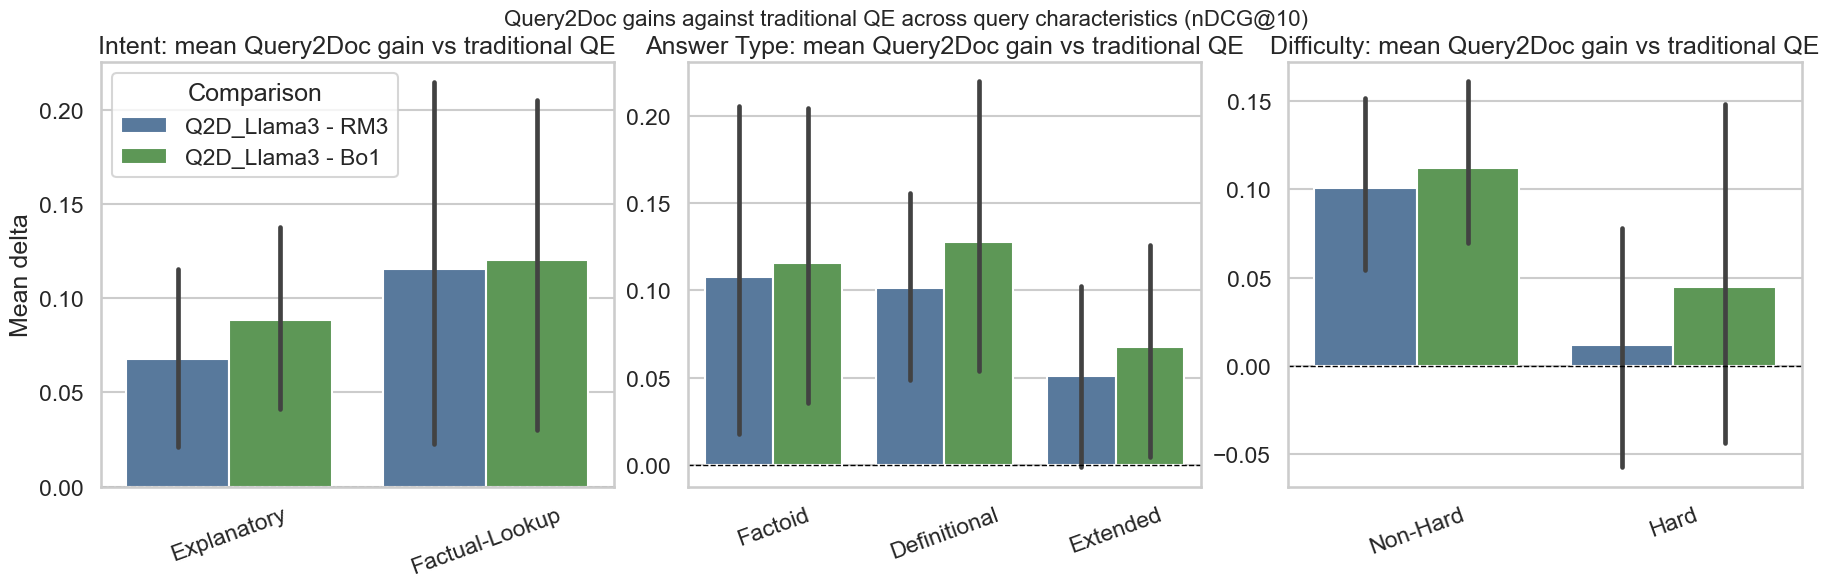

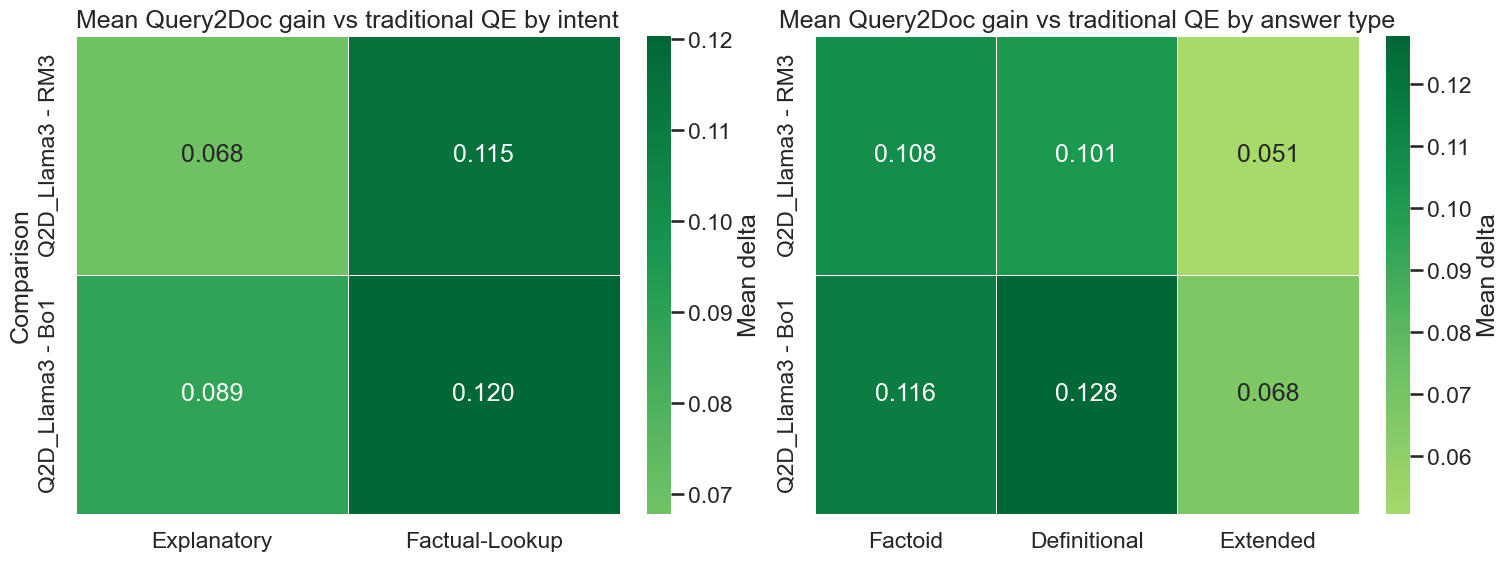

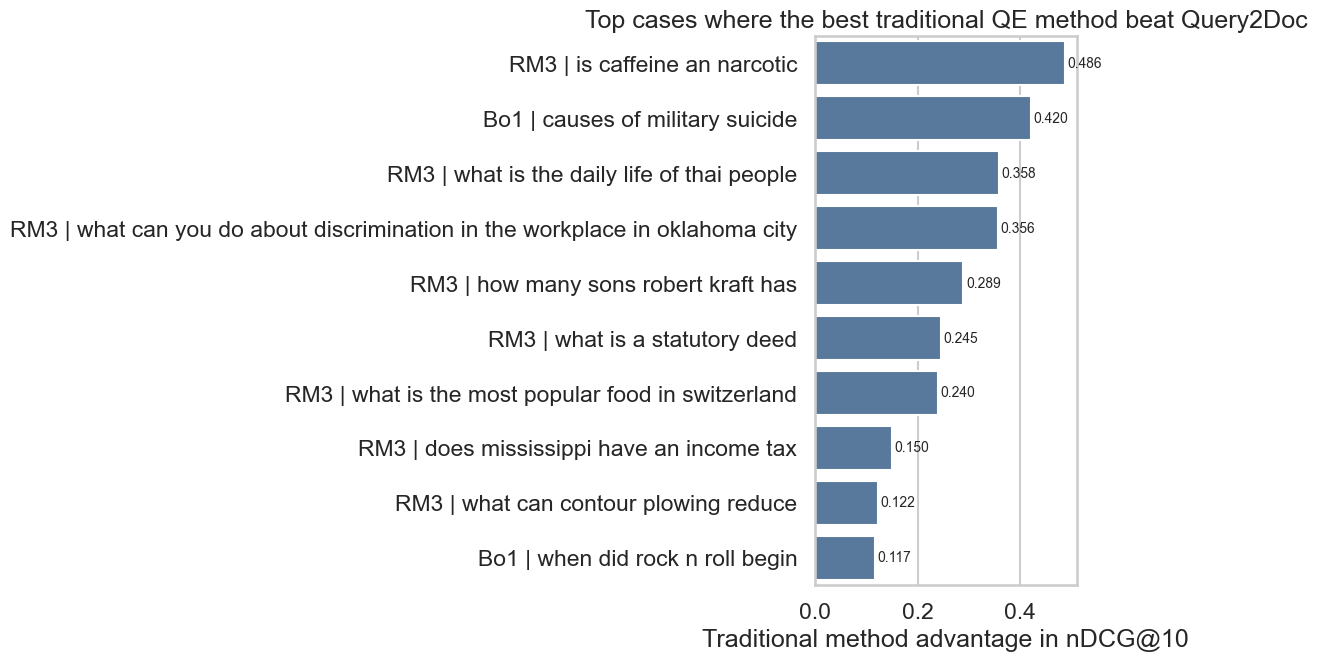

In [ ]:
# Statistical test changes: create report-ready visualizations for the revised query-type analysis
# and save them under figures/statistical-tests.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
stat_fig_dir = Path("figures") / "statistical-tests"
stat_fig_dir.mkdir(parents=True, exist_ok=True)

stat_comparison_palette = {
    f"{stat_target_method} - RM3": "#4C78A8",
    f"{stat_target_method} - Bo1": "#54A24B",
}
stat_difficulty_order = [
    group for group in ["Non-Hard", "Hard"]
    if group in stat_delta_results_common["difficulty_group"].dropna().unique()
]


def stat_save_figure(fig, stem):
    fig.savefig(stat_fig_dir / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(stat_fig_dir / f"{stem}.pdf", bbox_inches="tight")


def stat_annotate_bars(ax, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * 0.02 if ymax > ymin else 0.02
    for patch in ax.patches:
        height = patch.get_height()
        if np.isnan(height):
            continue
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + offset,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=10,
        )


main_metric = "nDCG@10"
group_specs = [
    ("meta_intent", stat_intent_order, "Intent"),
    ("meta_answer_type", stat_answer_type_order, "Answer Type"),
    ("difficulty_group", stat_difficulty_order, "Difficulty"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
for ax, (group_col, order, title) in zip(axes, group_specs):
    plot_df = stat_delta_results_common[
        (stat_delta_results_common["comparison"].isin(stat_comparison_order))
        & (stat_delta_results_common["measure"] == main_metric)
        & (stat_delta_results_common[group_col].notna())
    ].copy()
    sns.barplot(
        data=plot_df,
        x=group_col,
        y="delta",
        hue="comparison",
        order=order,
        hue_order=stat_comparison_order,
        palette=[stat_comparison_palette[name] for name in stat_comparison_order],
        ci=95,
        ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title}: mean Query2Doc gain vs traditional QE")
    ax.set_xlabel("")
    ax.set_ylabel("Mean delta" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=20)
    if ax is axes[0]:
        ax.legend(title="Comparison", frameon=True)
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
fig.suptitle("Query2Doc gains against traditional QE across query characteristics (nDCG@10)", y=1.04, fontsize=16)
stat_save_figure(fig, "query_types_q2d_vs_traditional_group_bars")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
for ax, group_col, order, title in [
    (axes[0], "meta_intent", stat_intent_order, "Mean Query2Doc gain vs traditional QE by intent"),
    (axes[1], "meta_answer_type", stat_answer_type_order, "Mean Query2Doc gain vs traditional QE by answer type"),
]:
    heatmap_df = (
        stat_delta_results_common[
            (stat_delta_results_common["measure"] == "nDCG@10")
            & (stat_delta_results_common[group_col].notna())
        ]
        .groupby(["comparison", group_col], as_index=False)["delta"]
        .mean()
        .pivot(index="comparison", columns=group_col, values="delta")
        .reindex(index=stat_comparison_order, columns=order)
    )
    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Mean delta"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Comparison" if ax is axes[0] else "")
stat_save_figure(fig, "query_types_q2d_gain_heatmaps")
plt.show()

failure_plot = (
    stat_failure_cases.sort_values("traditional_advantage", ascending=False)
    .head(10)
    .loc[:, ["query", "best_traditional_name", "traditional_advantage"]]
    .copy()
)
failure_plot["label"] = failure_plot["best_traditional_name"] + " | " + failure_plot["query"]

fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)
sns.barplot(
    data=failure_plot,
    y="label",
    x="traditional_advantage",
    color="#4C78A8",
    ax=ax,
)
ax.set_title("Top cases where the best traditional QE method beat Query2Doc")
ax.set_xlabel("Traditional method advantage in nDCG@10")
ax.set_ylabel("")
for patch in ax.patches:
    width = patch.get_width()
    if np.isnan(width):
        continue
    ax.text(width + 0.005, patch.get_y() + patch.get_height() / 2, f"{width:.3f}", va="center", fontsize=10)
stat_save_figure(fig, "query_types_failure_cases")
plt.show()


In [ ]:
from scipy.stats import wilcoxon

subgroup_rows = []

for group_col in ["meta_intent", "meta_answer_type"]:
    for group_val in stat_delta_results_common[group_col].dropna().unique():
        for comparison in stat_comparison_order:
            for measure in stat_metric_order:
                subset = stat_delta_results_common[
                    (stat_delta_results_common[group_col] == group_val)
                    & (stat_delta_results_common["comparison"] == comparison)
                    & (stat_delta_results_common["measure"] == measure)
                ]
                deltas = subset["delta"].dropna().values
                if len(deltas) < 5:
                    continue
                if (deltas == 0).all():
                    stat, p = 0.0, 1.0
                else:
                    stat, p = wilcoxon(deltas, alternative="two-sided")
                subgroup_rows.append(
                    {
                        "group_type": group_col,
                        "group_value": group_val,
                        "comparison": comparison,
                        "measure": measure,
                        "n": len(deltas),
                        "mean_delta": round(float(deltas.mean()), 4),
                        "median_delta": (
                            round(float(deltas.median()), 4)
                            if hasattr(deltas, "median")
                            else round(float(np.median(deltas)), 4)
                        ),
                        "wilcoxon_stat": round(float(stat), 4),
                        "p_value": float(p),
                    }
                )

subgroup_tests = pd.DataFrame(subgroup_rows)
subgroup_tests = stat_apply_holm(subgroup_tests, group_cols=["group_type"])

print("=== Per-subgroup Wilcoxon tests: Q2D vs traditional QE ===")
print(
    subgroup_tests.sort_values(["group_type", "measure", "p_corrected"]).to_string(
        index=False
    )
)

=== Per-subgroup Wilcoxon tests: Q2D vs traditional QE ===
      group_type    group_value       comparison      measure  n  mean_delta  median_delta  wilcoxon_stat  p_value  p_corrected  significant
meta_answer_type       Extended Q2D_Llama3 - Bo1    AP(rel=2) 42      0.0741        0.0407          145.0 0.000057     0.001367         True
meta_answer_type   Definitional Q2D_Llama3 - RM3    AP(rel=2) 21      0.1021        0.0595           15.0 0.000131     0.003005         True
meta_answer_type       Extended Q2D_Llama3 - RM3    AP(rel=2) 42      0.0650        0.0240          185.0 0.000586     0.012892         True
meta_answer_type   Definitional Q2D_Llama3 - Bo1    AP(rel=2) 21      0.1063        0.0505           33.0 0.002857     0.059238        False
meta_answer_type        Factoid Q2D_Llama3 - Bo1    AP(rel=2) 34      0.0858        0.0516          151.0 0.011235     0.179753        False
meta_answer_type        Factoid Q2D_Llama3 - RM3    AP(rel=2) 34      0.0827        0.0296     